# 09: KG + LLM Integration

*Does grounding an LLM in KG context improve drug–disease plausibility judgments, and which prompting strategies matter?*

This notebook poses 300 stratified drug–disease pairs (positives by Open Targets `max_phase`, negatives sampled both randomly and as "plausible hard negatives") to an LLM under three KG-context conditions and five prompting strategies, and measures accuracy, calibration, and consistency across runs.

| Axis | Levels | Comment |
|---|---|---|
| **KG context** | `with_kg`, `no_kg`, `shuffled_kg` | Pan et al. (2024) §IV-B-2 KG-Prompting; Li-style drug-side `drug_target` walk verbalised as one sentence per triple |
| **Prompt strategy** | 5 strategies (see below) | Each tests a distinct hypothesis from the biomedical-LLM literature |
| **Reseeds** | 3 per cell | Captures decoding noise; reported alongside accuracy |

**Prompting strategies** (see `src/prompting_strategies.py` and [`docs/llm_prompting_strategies.md`](../docs/llm_prompting_strategies.md)):

- **Restricted (constrained output schema):** `zero_shot_direct` (baseline), `structured_json` (JSON with explicit *contradictions* field)
- **Unrestricted (open-ended reasoning):** `zero_shot_cot` (chain-of-thought), `multi_expert_rot` (3-expert deliberation, Wang et al. 2024), `cisc` (Confidence-Informed Self-Consistency, Taubenfeld et al. 2025)

**Headline metric.** `KG-lift = accuracy(with_kg) − accuracy(shuffled_kg)`, plotted against BioKGSuite intrinsic quality. Per-strategy comparisons add accuracy, calibration, and parse-rate axes.

**Inputs:** `config.yaml` · KG edge files · gold-standard crosswalks (DrugBank, DOID, MeSH, MONDO SSSOM) · local Ollama server with `llama3.1:8b` pulled

**Outputs:** `results/tables/09_llm_runs/responses.parquet` · `results/figures/09_*.{pdf,png}` · `results/checkpoints/09_llm_kg_*.pkl`


In [1]:
# Setup
import sys, json, re, gc, time, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm import tqdm

BASE = Path('/Users/shil6661/biokgsuite')
if not BASE.exists():
    BASE = Path('/sessions/friendly-focused-edison/mnt/biokgsuite')
sys.path.insert(0, str(BASE / 'src'))
from loading import load_kg, load_config, find_config
from prompting_strategies import STRATEGIES, get_strategy, total_calls_per_cell
from graph_utils import build_graph, build_lookup_maps

config  = load_config(find_config(BASE))
GOLD    = BASE / 'data' / 'gold_standards'
FIGS   = BASE / 'results' / 'figures';   FIGS.mkdir(parents=True, exist_ok=True)
TABLES = BASE / 'results' / 'tables' / '09_llm_runs'
TABLES.mkdir(parents=True, exist_ok=True)


In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────
# Stratified positives (Open Targets max_phase) + two negative samplings
N_POS_APPROVED   = 50    # is_approved=True, max_phase=4
N_POS_PHASE3     = 50    # max_phase==3, not approved
N_POS_PHASE12    = 50    # max_phase in {1, 2}
N_NEG_RANDOM     = 75    # drug × random OT disease (current style)
N_NEG_PLAUSIBLE  = 75    # drug × disease another drug treats (hard negs)
RANDOM_SEED      = 42

N_POSITIVES = N_POS_APPROVED + N_POS_PHASE3 + N_POS_PHASE12
N_NEGATIVES = N_NEG_RANDOM   + N_NEG_PLAUSIBLE
KGS           = ['biokg', 'drkg', 'hetionet', 'matrix', 'openbilink', 'primekg']
MAX_EDGES     = 20
N_RESEEDS     = 3
LLM_TAG       = 'llama3.1:8b'
OLLAMA_URL    = 'http://localhost:11434/api/generate'
TEMPERATURE   = 0.0
MAX_TOKENS    = 50
CONDITIONS    = ['with_kg', 'no_kg', 'shuffled_kg']

PAIRS_FP      = TABLES / 'pairs.parquet'
RESPONSES_FP  = TABLES / 'responses.parquet'

n_pairs = N_POSITIVES + N_NEGATIVES
n_cells = n_pairs * len(CONDITIONS) * N_RESEEDS * len(KGS)
print(f'{n_pairs} pairs × {len(KGS)} KGs × {len(CONDITIONS)} conditions × {N_RESEEDS} reseeds = {n_cells:,} LLM calls')

# ── PROMPTING STRATEGIES (new) ─────────────────────────────────────────
# 8 new strategies + the original baseline. See src/prompting_strategies.py.
STRATEGIES_TO_RUN = [
    # 5 literature-grounded strategies, 2 restricted + 3 unrestricted.
    # See docs/llm_prompting_strategies.md for per-strategy citations.
    # RESTRICTED — constrained output schema:
    'zero_shot_direct',     # baseline: Sivarajkumar et al. 2024 (JMIR Med Inf)
    'structured_json',      # DrugReX 2025, DrugReAlign 2024 (BMC Biology)
    # UNRESTRICTED — open-ended reasoning:
    'zero_shot_cot',        # Sivarajkumar et al. 2024; Jeon et al. 2025
    'multi_expert_rot',     # Wang et al. 2024, npj Digital Medicine (ROT, best on gpt-4-Web)
    'cisc',                 # Confidence-Informed Self-Consistency, Taubenfeld et al. 2025
]
# To save calls, new strategies skip the shuffled_kg control condition.
# zero_shot_direct under shuffled_kg already exists in the cache.
SKIP_SHUFFLED_FOR = {s for s in STRATEGIES_TO_RUN if s != 'zero_shot_direct'}

# Print updated call-budget estimate
from prompting_strategies import STRATEGIES as _ST, total_calls_per_cell
_total_strats = total_calls_per_cell(STRATEGIES_TO_RUN)
print(f'Strategies enabled: {STRATEGIES_TO_RUN}')
print(f'Sum of n_calls per cell across all strategies: {_total_strats}')
# Compute realistic n_cells given the reduced cross
_cells = 0
for s in STRATEGIES_TO_RUN:
    conds = [c for c in CONDITIONS if not (s in SKIP_SHUFFLED_FOR and c == 'shuffled_kg')]
    _cells += n_pairs * len(conds) * N_RESEEDS * len(KGS) * _ST[s].n_calls
print(f'Total LLM calls across strategies (n_pairs={n_pairs}): {_cells:,}')


300 pairs × 6 KGs × 3 conditions × 3 reseeds = 16,200 LLM calls


## 1 · Pair sampling

`N_POSITIVES` indicated pairs from Open Targets + `N_NEGATIVES` matched non-indications (real drug, real disease, not indicated).


In [3]:
if PAIRS_FP.exists():
    pairs = pd.read_parquet(PAIRS_FP)
else:
    ind = pd.read_csv(GOLD / 'opentargets_drug_indications.csv')
    ind['drug_id'] = ind['drugbank_id']
    def _norm_mondo(v):
        s = str(v).strip().replace('MONDO:', '')
        try:    return f'MONDO:{int(float(s))}' if s not in ('', 'nan') else None
        except (ValueError, OverflowError): return None
    ind['disease_id'] = ind['mondo_id'].fillna(ind['mondo_id_mapped']).map(_norm_mondo)
    ind = ind.dropna(subset=['drug_id', 'disease_id', 'drug_name', 'disease_name'])
    rng = np.random.default_rng(RANDOM_SEED)

    # ── stratified positives ────────────────────────────────────────────
    pool_approved = ind[ind['is_approved'] == True]
    pool_phase3   = ind[(ind['max_phase'] == 3) & (ind['is_approved'] != True)]
    pool_phase12  = ind[ind['max_phase'].isin([1.0, 2.0])]
    print(f'OT pools — approved: {len(pool_approved):,}  phase3: {len(pool_phase3):,}  phase12: {len(pool_phase12):,}')

    pos_a = pool_approved.sample(n=N_POS_APPROVED, random_state=RANDOM_SEED).assign(stratum='approved', label=1)
    pos_3 = pool_phase3.sample  (n=N_POS_PHASE3,   random_state=RANDOM_SEED+1).assign(stratum='phase3',   label=1)
    pos_1 = pool_phase12.sample (n=N_POS_PHASE12,  random_state=RANDOM_SEED+2).assign(stratum='phase12',  label=1)
    pos = pd.concat([pos_a, pos_3, pos_1], ignore_index=True)

    # ── negatives: random + plausible ───────────────────────────────────
    drug_to_dis = ind.groupby('drug_id')['disease_id'].apply(set).to_dict()
    all_diseases = ind[['disease_id', 'disease_name']].drop_duplicates()
    approved_pool_diseases = pool_approved[['disease_id', 'disease_name']].drop_duplicates()  # for plausible negs
    drug_pool = pos[['drug_id', 'drug_name']].drop_duplicates().to_dict('records')

    def _draw_negs(n_target, disease_pool, neg_type):
        rows = []
        for _ in range(n_target * 8):           # over-sample, dedupe via the set membership check
            d = drug_pool[int(rng.integers(len(drug_pool)))]
            x = disease_pool.sample(n=1, random_state=int(rng.integers(2**31))).iloc[0]
            if x['disease_id'] in drug_to_dis.get(d['drug_id'], set()): continue
            rows.append({'drug_id': d['drug_id'], 'drug_name': d['drug_name'],
                         'disease_id': x['disease_id'], 'disease_name': x['disease_name'],
                         'stratum': neg_type, 'label': 0})
            if len(rows) >= n_target: break
        return rows

    neg_rand = _draw_negs(N_NEG_RANDOM,   all_diseases,            'neg_random')
    neg_plaus= _draw_negs(N_NEG_PLAUSIBLE, approved_pool_diseases, 'neg_plausible')
    neg = pd.DataFrame(neg_rand + neg_plaus)

    pairs = pd.concat([pos[['drug_id','drug_name','disease_id','disease_name','stratum','label']], neg],
                      ignore_index=True)
    pairs['pair_idx'] = range(len(pairs))
    pairs.to_parquet(PAIRS_FP, index=False)

print(f'{len(pairs)} pairs total')
print(pairs.groupby(['stratum', 'label']).size().rename('n'))
pairs.head()


300 pairs total
stratum        label
approved       1        50
neg_plausible  0        75
neg_random     0        75
phase12        1        50
phase3         1        50
Name: n, dtype: int64


,drug_id,drug_name,disease_id,disease_name,stratum,label,pair_idx
0,DB01248,DOCETAXEL ANHYDROUS,MONDO:4950,gastric carcinoma,approved,1,0
1,DB00877,SIROLIMUS,MONDO:1734,tuberous sclerosis,approved,1,1
2,DB08897,ACLIDINIUM,MONDO:4849,emphysema,approved,1,2
3,DB01104,SERTRALINE,MONDO:5146,post-traumatic stress disorder,approved,1,3
4,DB00625,EFAVIRENZ,MONDO:21094,immunodeficiency disease,approved,1,4


## 2 · ID crosswalks (mirrors nb01)

Same gold-standard tables and bridges that `01_coverage.ipynb` uses (`do_diseases`, `mesh_to_doid`, `uniprot_genesproteins`, OpenBioLink's PubChem map, DrugBank xref), plus MONDO SSSOM for the long-tail UMLS/OMIM/Orphanet mappings.


In [4]:
drugbank  = pd.read_csv(GOLD / 'drugbank_drugs.csv', low_memory=False)
do        = pd.read_csv(GOLD / 'do_diseases.csv')
mesh_doid = pd.read_csv(GOLD / 'mesh_to_doid.csv', on_bad_lines='skip')
uniprot   = pd.read_csv(GOLD / 'uniprot_genesproteins.csv', low_memory=False)
xref      = pd.read_csv(GOLD / 'drugbank_xref.csv')
sssom     = pd.read_csv(GOLD / 'mondo.sssom.tsv', sep='\t', comment='#')
sssom     = sssom[sssom['predicate_id'] == 'skos:exactMatch']

# MONDO ↔ DOID  (many-to-many)
_do = do.dropna(subset=['mondo_id', 'doid']).copy()
_do['m'] = _do['mondo_id'].str.replace('MONDO:', '', regex=False).str.lstrip('0').replace({'': '0'})
_do['d'] = _do['doid'].str.replace('DOID:', '', regex=False).str.lstrip('0').replace({'': '0'})
mondo_to_doid_all = defaultdict(set); doid_to_mondo_all = defaultdict(set)
for _, r in _do.iterrows():
    mondo_to_doid_all[r['m']].add(r['d']); doid_to_mondo_all[r['d']].add(r['m'])

# MESH ↔ DOID  (DO source wins over MONDO source)
mesh_doid['mesh_clean'] = mesh_doid['mesh_id'].str.replace(r'\s*\{.*\}', '', regex=True).str.strip()
_mh = (mesh_doid.assign(src_rank=mesh_doid['source'].map({'DO': 0, 'MONDO': 1}).fillna(2))
                .sort_values('src_rank').drop_duplicates('mesh_clean', keep='first'))
mesh_to_doid = {r['mesh_clean']: (r['doid'].replace('DOID:', '').lstrip('0') or '0')
                for _, r in _mh.iterrows() if pd.notna(r['doid'])}
doid_to_mesh = defaultdict(set)
for m, d in mesh_to_doid.items():
    if m.startswith('MESH:'): doid_to_mesh[d].add(m)

# OpenBioLink PubChem → DrugBank (from project crosswalk file)
_obl_db_to_pc = defaultdict(set); _obl_pc_to_db = {}
pc_path = BASE / 'data' / 'openbilink' / 'pubchem_to_drugbank.csv'
if pc_path.exists():
    _pc = pd.read_csv(pc_path)
    for pc, db in zip(_pc.iloc[:, 0].astype(str), _pc.iloc[:, 1].astype(str)):
        if db.startswith('DB'): _obl_pc_to_db[pc] = db; _obl_db_to_pc[db].add(pc)

# DrugBank cross-namespace xref (CID, ChEMBL, ChEBI, RxCUI, …)
drug_equiv = defaultdict(set)
for db, ns, eid in zip(xref.drugbank_id.astype(str), xref.namespace.astype(str), xref.external_id.astype(str)):
    drug_equiv[db].update({f'{ns}:{eid}', eid})
    if ns == 'PUBCHEM.COMPOUND': drug_equiv[db].update({f'CID:{eid}', f'pubchem.compound:{eid}'})

# SSSOM disease equivalents
_eq = defaultdict(set)
for s, o in zip(sssom['subject_id'], sssom['object_id']):
    _eq[s].add(o); _eq[o].add(s)
disease_equiv = defaultdict(set)
for k, vs in _eq.items():
    s = set(vs)
    for v in vs: s |= _eq.get(v, set())
    s.discard(k); disease_equiv[k] = s

print(f'mondo_to_doid_all: {len(mondo_to_doid_all):,}  |  mesh_to_doid: {len(mesh_to_doid):,}  '
      f'|  drug_equiv: {len(drug_equiv):,}  |  sssom: {len(disease_equiv):,}')


mondo_to_doid_all: 11,767  |  mesh_to_doid: 4,913  |  drug_equiv: 17,687  |  sssom: 133,771


## 3 · Inverse resolvers

`to_kg_drug_ids(drugbank_id, kg_name)` and `to_kg_disease_ids(mondo_id, kg_name)` return the set of ID forms each KG might index the entity under. Result is fed to type-aware `_tc()` in the main loop.


In [5]:
_BARE_MESH = re.compile(r'^[DC]\d+$')

def _variants(cands):
    out = set(cands)
    for c in list(cands):
        if not isinstance(c, str): continue
        if ':' in c:
            ns, _, rest = c.partition(':')
            out.update({c.replace(':', '_', 1), f'{ns.upper()}:{rest}', f'{ns.lower()}:{rest}', rest})
            try:
                stripped = str(int(rest))
                if stripped != rest: out.add(stripped)
            except (ValueError, TypeError): pass
        if '_' in c and ':' not in c:
            out.add(c.replace('_', ':', 1))
    return out

def to_kg_drug_ids(db_id, kg_name):
    s = str(db_id).strip()
    cands = {s} | drug_equiv.get(s, set())
    if kg_name == 'openbilink':
        for pc in _obl_db_to_pc.get(s, set()):
            cands.update({f'PUBCHEM.COMPOUND:{pc}', f'PUBCHEM.COMPOUND_{pc}', pc})
    return _variants(cands)

def to_kg_disease_ids(disease_id, kg_name):
    s = str(disease_id).strip()
    scheme = config['knowledge_graphs'][kg_name].get('disease_id_scheme', 'doid')

    # Normalise input to a bare MONDO numeric
    if   s.startswith('MONDO:'):  mondo = s.replace('MONDO:', '').lstrip('0') or '0'
    elif s.startswith('DOID:'):   mondo = (sorted(doid_to_mondo_all.get(s.replace('DOID:', '').lstrip('0') or '0', ['?']))[0])
    elif _BARE_MESH.match(s):     d = mesh_to_doid.get(f'MESH:{s}'); mondo = sorted(doid_to_mondo_all.get(d, ['?']))[0] if d else '?'
    else:                         mondo = s.lstrip('0') or '0'

    cands = set()
    if scheme == 'mondo':
        cands.update({mondo, mondo.zfill(7), f'MONDO:{mondo}'})
    elif scheme == 'doid':
        for d in mondo_to_doid_all.get(mondo, set()):
            cands.update({d, f'DOID:{d}'})
    elif scheme == 'doid_mesh':
        for d in mondo_to_doid_all.get(mondo, set()):
            cands.update({d, f'DOID:{d}'}); cands |= doid_to_mesh.get(d, set())
    elif scheme == 'mesh':
        for d in mondo_to_doid_all.get(mondo, set()):
            for m in doid_to_mesh.get(d, set()): cands.update({m, m.split(':', 1)[-1]})

    # SSSOM expansion
    for c in list(cands) + [f'MONDO:{mondo}']:
        cands |= disease_equiv.get(c, set())
    return _variants(cands)


## 4 · Li-style retrieval + verbalisation

Direct drug→gene edges with a configured `drug_target` predicate. Predicates are mapped to plain English so each KG looks the same to the LLM (no KG-specific jargon to give the model away).


In [6]:
PREDICATE_NORMALIZE = {
    # PrimeKG / BioKG / Hetionet / DRKG
    'drug_protein': 'targets',  'DPI': 'targets',  'CbG': 'binds',
    'DRUGBANK::target::Compound:Gene':      'targets',
    'DRUGBANK::enzyme::Compound:Gene':      'is metabolised by',
    'DRUGBANK::carrier::Compound:Gene':     'is carried by',
    'DRUGBANK::transporter::Compound:Gene': 'is transported by',
    # OpenBioLink
    'DRUG_BINDING_GENE':   'binds',     'DRUG_BINDACT_GENE':   'binds and activates',
    'DRUG_BINDINH_GENE':   'binds and inhibits',
    'DRUG_ACTIVATION_GENE':'activates', 'DRUG_INHIBITION_GENE':'inhibits',
    'DRUG_CATALYSIS_GENE': 'is catalysed by', 'DRUG_REACTION_GENE': 'reacts with',
    # Matrix (biolink)
    'directly_physically_interacts_with': 'directly binds',
    'physically_interacts_with':          'physically interacts with',
    'interacts_with':                     'interacts with',
    'affects':                            'affects',
}

def normalise_predicate(raw):
    s = str(raw)
    if s in PREDICATE_NORMALIZE: return PREDICATE_NORMALIZE[s]
    stripped = re.sub(r'^(biolink:|RO:|SIO:|oio:)', '', s)
    return PREDICATE_NORMALIZE.get(stripped, stripped.replace('_', ' '))

def mech_rels(kg_name):
    dt = config['knowledge_graphs'][kg_name].get('relations', {}).get('drug_target', {})
    return set([dt['relation']]) if 'relation' in dt else set(dt.get('relations', []))

def build_edge_index(kg_df):
    ix = defaultdict(list)
    for x, y, r in zip(kg_df['x_index'].values, kg_df['y_index'].values, kg_df['relation'].values):
        u, v, rs = int(x), int(y), str(r)
        ix[u].append((v, rs)); ix[v].append((u, rs))
    return ix

def retrieve_li(drug_idx, edge_index, type_map, kg_name, max_edges=MAX_EDGES):
    if drug_idx is None: return []
    gene_t = config['knowledge_graphs'][kg_name]['entity_types'].get('Gene/Protein')
    mech   = mech_rels(kg_name)
    out = []
    for v, e_rel in edge_index.get(drug_idx, []):
        if type_map.get(v) != gene_t: continue
        if mech and not (e_rel in mech or any(m in e_rel for m in mech)): continue
        out.append((drug_idx, v, {'relation': e_rel}))
        if len(out) >= max_edges: break
    return out

def verbalize(edges, name_map):
    return '\n'.join(
        f"{name_map.get(u, u)} {normalise_predicate(d['relation'])} {name_map.get(v, v)}."
        for u, v, d in edges
    )


## 5 · Prompt template + LLM client


In [7]:
PROMPT = (
    'You are a drug repurposing expert. Below is knowledge-graph context about a drug, '
    'followed by a yes/no question.\n\n'
    '{kg_block}\n\n'
    'Question: Is {drug_name} a plausible treatment for {disease_name}?\n'
    'Respond on one line: "Answer: <Yes|No>, Confidence: <1-5>".'
)

def build_prompt(drug, disease, kg_text):
    kg_block = f'Knowledge graph context:\n{kg_text}' if kg_text else 'No knowledge graph context provided.'
    return PROMPT.format(kg_block=kg_block, drug_name=drug, disease_name=disease)

_YES  = re.compile(r'\banswer\s*[:\-]?\s*y(?:es)?\b', re.I)
_NO   = re.compile(r'\banswer\s*[:\-]?\s*no\b',      re.I)
_CONF = re.compile(r'confidence\s*[:\-]?\s*([1-5])',   re.I)

def parse_yesno(text):
    if not text: return None, None
    head = text.strip()[:40].lower()
    pred = 1 if (_YES.search(head) or head.lstrip().startswith('yes')) else \
           0 if (_NO.search(head)  or head.lstrip().startswith('no'))  else None
    m = _CONF.search(text)
    return pred, (int(m.group(1)) if m else None)

def ollama_query(prompt, seed=0, temperature=None, max_tokens=None, format=None):
    """Send one prompt to Ollama. New kwargs let prompting strategies override
    decoding (temperature, num_predict) and request JSON-mode output."""
    options = {'temperature': TEMPERATURE if temperature is None else temperature,
               'num_predict': MAX_TOKENS if max_tokens is None else max_tokens,
               'seed': int(seed)}
    payload = {'model': LLM_TAG, 'prompt': prompt, 'stream': False, 'options': options}
    if format is not None:
        payload['format'] = format   # e.g. 'json' for structured-output strategy
    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=120); r.raise_for_status()
        return {'response': r.json().get('response', ''), 'error': None}
    except Exception as e:
        return {'response': '', 'error': str(e)}

tags = {m['name'] for m in requests.get('http://localhost:11434/api/tags', timeout=3).json().get('models', [])}
print(f'Ollama up — {LLM_TAG} {"✓" if LLM_TAG in tags else "✗ MISSING"}')


ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/tags (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [Errno 61] Connection refused"))

## 6 · Main loop

Per KG: load, build edge index, resolve drug + disease anchors (diagnostic), retrieve Li-style triples, then run every `(pair × condition × reseed)` cell. Resume-safe via `completed_keys`.


In [ ]:
def completed_keys(fp):
    if not fp.exists(): return set()
    df = pd.read_parquet(fp, columns=['llm','kg','condition','pair_idx','reseed','error'])
    df = df[df['error'].isna()]
    return set(zip(df.llm, df.kg, df.condition, df.pair_idx, df.reseed))

def append_rows(rows, fp):
    df = pd.DataFrame(rows)
    if fp.exists():
        df = pd.concat([pd.read_parquet(fp), df], ignore_index=True)\
               .sort_values('ts')\
               .drop_duplicates(['llm','kg','condition','pair_idx','reseed'], keep='last')
    df.to_parquet(fp, index=False)

done = completed_keys(RESPONSES_FP)
print(f'Resuming — {len(done):,} cells already complete')

pairs_by_idx = {int(r['pair_idx']): r for _, r in pairs.iterrows()}
pids         = sorted(pairs_by_idx)
perm         = {pid: pids[(i + 1) % len(pids)] for i, pid in enumerate(pids)}

buf = []
for kg_name in KGS:
    print(f'\n=== {kg_name} ===')
    try:
        kg_df, nodes_df = load_kg(kg_name, config)
    except Exception as e:
        print(f'  [skip] {e}'); continue

    mp = build_lookup_maps(nodes_df)
    type_map, name_map = mp['node_type_map'], mp['node_name_map']
    idx_to_type = dict(zip(nodes_df['idx'].astype(int), nodes_df['type'].astype(str)))

    # Multi-value id_to_idx — wrong-type collisions can't shadow the right node
    id_to_idx = defaultdict(list)
    for raw, idx in zip(nodes_df['id'].astype(str), nodes_df['idx'].astype(int)):
        for k in {raw, raw.split('::', 1)[-1] if '::' in raw else raw}:
            id_to_idx[k].append((idx, idx_to_type.get(idx)))

    et         = config['knowledge_graphs'][kg_name]['entity_types']
    drug_t     = et.get('Drug')
    disease_t  = et.get('Disease')
    def _tc(cands, want):
        for c in cands:
            for idx, t in id_to_idx.get(c, []):
                if t == want: return idx
        return None
    resolve_drug    = lambda db_id: _tc(to_kg_drug_ids(db_id, kg_name), drug_t)
    resolve_disease = lambda d_id:  _tc(to_kg_disease_ids(d_id, kg_name), disease_t)

    edge_index = build_edge_index(kg_df)

    # Retrieve per-pair (drug-side walk; disease anchor logged only)
    subgraph_text, n_d, n_x = {}, 0, 0
    for pi in pids:
        row = pairs_by_idx[pi]
        d_idx = resolve_drug(row['drug_id']);    n_d += d_idx is not None
        n_x  += resolve_disease(row['disease_id']) is not None
        subgraph_text[pi] = verbalize(retrieve_li(d_idx, edge_index, type_map, kg_name), name_map)
    n_content = sum(1 for t in subgraph_text.values() if t)
    print(f'  anchors: drug={n_d}/{len(pids)}, disease={n_x}/{len(pids)}  |  with content: {n_content}/{len(pids)}')

    for pi in tqdm(pids, desc=f'  {kg_name}', leave=False):
        row = pairs_by_idx[pi]
        kg_text = {'with_kg': subgraph_text[pi], 'shuffled_kg': subgraph_text[perm[pi]], 'no_kg': ''}
        for cond in CONDITIONS:
            for reseed in range(N_RESEEDS):
                key = (LLM_TAG, kg_name, cond, pi, reseed)
                if key in done: continue
                out = ollama_query(build_prompt(row['drug_name'], row['disease_name'], kg_text[cond]),
                                   seed=RANDOM_SEED + reseed * 1000 + pi)
                pred, conf = parse_yesno(out['response'])
                buf.append({
                    'llm': LLM_TAG, 'kg': kg_name, 'condition': cond,
                    'pair_idx': pi, 'reseed': reseed,
                    'drug_name': row['drug_name'], 'disease_name': row['disease_name'],
                    'label': int(row['label']),
                    'label_pred': pred, 'confidence': conf,
                    'correct': (pred == int(row['label'])) if pred is not None else False,
                    'n_kg_edges': kg_text[cond].count('.') if kg_text[cond] else 0,
                    'response': out['response'], 'error': out['error'], 'ts': time.time(),
                })
                if len(buf) >= 20: append_rows(buf, RESPONSES_FP); buf = []
    if buf: append_rows(buf, RESPONSES_FP); buf = []
    del kg_df, nodes_df, edge_index; gc.collect()

print('\nDone.')


Resuming — 0 cells already complete

=== biokg ===
  anchors: drug=283/300, disease=171/300  |  with content: 270/300



=== drkg ===
  anchors: drug=295/300, disease=197/300  |  with content: 264/300



=== hetionet ===
  anchors: drug=202/300, disease=26/300  |  with content: 201/300



=== matrix ===
  matrix: loading from cache _cache_matrix_88f004a4_kg.parquet / _cache_matrix_88f004a4_nodes.parquet
  matrix: cached load — 2,850,122 nodes, 41,595,079 edges
  anchors: drug=228/300, disease=292/300  |  with content: 223/300



=== openbilink ===
  anchors: drug=246/300, disease=201/300  |  with content: 166/300



=== primekg ===
  anchors: drug=282/300, disease=229/300  |  with content: 268/300



Done.


## 9 · Prompting strategy experiments

The cells below add 8 new prompting strategies alongside the original zero-shot baseline, and rerun the loop over (strategy × kg × condition × pair × reseed). New strategies skip the `shuffled_kg` control to save calls (the `zero_shot_direct/shuffled_kg` numbers already exist).

See `src/prompting_strategies.py` for templates and `docs/llm_prompting_strategies.md` for the experimental hypothesis behind each strategy.

In [ ]:
# ── Strategy-aware main loop ───────────────────────────────────────────
# Iterates over (strategy × kg × condition × pair × reseed). Reuses the
# same edge_index / retrieve_li / verbalize as the original loop. Each cell
# becomes ONE row in responses.parquet (multi-call strategies aggregate
# internally, see src/prompting_strategies.py).

from prompting_strategies import STRATEGIES, get_strategy

def completed_keys_with_strategy(fp):
    if not fp.exists(): return set()
    df = pd.read_parquet(fp, columns=['llm','kg','strategy','condition','pair_idx','reseed','error'])
    df = df[df['error'].isna()]
    if 'strategy' not in df.columns:
        return set()
    return set(zip(df.llm, df.kg, df.strategy, df.condition, df.pair_idx, df.reseed))

done = completed_keys_with_strategy(RESPONSES_FP)
# Also count old rows (no 'strategy' column) so we know how many are pre-strategy
if RESPONSES_FP.exists():
    _all = pd.read_parquet(RESPONSES_FP)
    n_legacy = int(_all.get('strategy', pd.Series(dtype=object)).isna().sum()) if 'strategy' in _all.columns else len(_all)
    print(f'Resuming — {len(done):,} strategy-aware cells complete, '
          f'{n_legacy:,} legacy rows (treated as zero_shot_direct/with_kg if matching)')
else:
    print('Fresh run — no responses.parquet yet')

pairs_by_idx = {int(r['pair_idx']): r for _, r in pairs.iterrows()}
pids         = sorted(pairs_by_idx)
perm         = {pid: pids[(i + 1) % len(pids)] for i, pid in enumerate(pids)}

buf = []
for kg_name in KGS:
    print(f'\n=== {kg_name} ===')
    try:
        kg_df, nodes_df = load_kg(kg_name, config)
    except Exception as e:
        print(f'  [skip] {e}'); continue

    mp = build_lookup_maps(nodes_df)
    type_map, name_map = mp['node_type_map'], mp['node_name_map']
    idx_to_type = dict(zip(nodes_df['idx'].astype(int), nodes_df['type'].astype(str)))

    id_to_idx = defaultdict(list)
    for raw, idx in zip(nodes_df['id'].astype(str), nodes_df['idx'].astype(int)):
        for k in {raw, raw.split('::', 1)[-1] if '::' in raw else raw}:
            id_to_idx[k].append((idx, idx_to_type.get(idx)))

    et         = config['knowledge_graphs'][kg_name]['entity_types']
    drug_t     = et.get('Drug')
    disease_t  = et.get('Disease')
    def _tc(cands, want):
        for c in cands:
            for idx, t in id_to_idx.get(c, []):
                if t == want: return idx
        return None
    resolve_drug    = lambda db_id: _tc(to_kg_drug_ids(db_id, kg_name), drug_t)
    resolve_disease = lambda d_id:  _tc(to_kg_disease_ids(d_id, kg_name), disease_t)

    edge_index = build_edge_index(kg_df)

    subgraph_text, n_d, n_x = {}, 0, 0
    for pi in pids:
        row = pairs_by_idx[pi]
        d_idx = resolve_drug(row['drug_id']);    n_d += d_idx is not None
        n_x  += resolve_disease(row['disease_id']) is not None
        subgraph_text[pi] = verbalize(retrieve_li(d_idx, edge_index, type_map, kg_name), name_map)
    n_content = sum(1 for t in subgraph_text.values() if t)
    print(f'  anchors: drug={n_d}/{len(pids)}, disease={n_x}/{len(pids)}  |  with content: {n_content}/{len(pids)}')

    for strategy_name in STRATEGIES_TO_RUN:
        strat = get_strategy(strategy_name)
        # Reduced cross: skip shuffled_kg for new strategies
        conds_for_strat = [c for c in CONDITIONS
                           if not (strategy_name in SKIP_SHUFFLED_FOR and c == 'shuffled_kg')]
        print(f'  -- strategy={strategy_name} ({strat.n_calls}-call) | conditions={conds_for_strat}')

        for pi in tqdm(pids, desc=f'    {strategy_name}/{kg_name}', leave=False):
            row = pairs_by_idx[pi]
            kg_text = {'with_kg': subgraph_text[pi],
                       'shuffled_kg': subgraph_text[perm[pi]],
                       'no_kg': ''}
            for cond in conds_for_strat:
                for reseed in range(N_RESEEDS):
                    key = (LLM_TAG, kg_name, strategy_name, cond, pi, reseed)
                    if key in done: continue
                    result = strat.execute(
                        ollama_query, row['drug_name'], row['disease_name'],
                        kg_text[cond],
                        seed=RANDOM_SEED + reseed * 1000 + pi)
                    buf.append({
                        'llm': LLM_TAG, 'kg': kg_name, 'strategy': strategy_name,
                        'condition': cond, 'pair_idx': pi, 'reseed': reseed,
                        'drug_name': row['drug_name'], 'disease_name': row['disease_name'],
                        'label': int(row['label']),
                        'label_pred': result['pred'], 'confidence': result['confidence'],
                        'correct': (result['pred'] == int(row['label']))
                                    if result['pred'] is not None else False,
                        'n_kg_edges': kg_text[cond].count('.') if kg_text[cond] else 0,
                        'n_calls_made': result['n_calls_made'],
                        'response': result['response'], 'error': result['error'],
                        'ts': time.time(),
                    })
                    if len(buf) >= 20:
                        append_rows(buf, RESPONSES_FP); buf = []
            if buf:
                append_rows(buf, RESPONSES_FP); buf = []
    del kg_df, nodes_df, edge_index; gc.collect()

print('\nStrategy-aware run done.')


### Strategy-level metrics, parse rates, call cost

In [ ]:
# ── Strategy-aware metrics ─────────────────────────────────────────────
r = pd.read_parquet(RESPONSES_FP)
# Backfill legacy rows (pre-strategy) as zero_shot_direct
if 'strategy' not in r.columns:
    r['strategy'] = 'zero_shot_direct'
else:
    r['strategy'] = r['strategy'].fillna('zero_shot_direct')

r = r[r['error'].isna() & r['label_pred'].notna()].copy()
r['label_pred'] = r['label_pred'].astype(int)
r = r.merge(pairs[['pair_idx', 'stratum']], on='pair_idx', how='left')

print(f'Analyzing {len(r):,} valid response rows '
      f'across {r["strategy"].nunique()} strategies, '
      f'{r["kg"].nunique()} KGs, {r["condition"].nunique()} conditions.')

# Overall accuracy per (strategy, condition) — averaged across KGs
print('\n=== Accuracy by strategy × condition (averaged across KGs) ===')
strat_acc = r.groupby(['strategy', 'condition'])['correct'].agg(['mean', 'count'])
strat_acc.columns = ['accuracy', 'n']
strat_acc['accuracy'] = strat_acc['accuracy'].round(3)
print(strat_acc.to_string())

# Parse rate per strategy (fraction of responses that yielded a valid pred)
print('\n=== Parse rate by strategy ===')
_all = pd.read_parquet(RESPONSES_FP)
if 'strategy' not in _all.columns:
    _all['strategy'] = 'zero_shot_direct'
_all = _all[_all['error'].isna()]
parse_rate = (_all.groupby('strategy')
                  .apply(lambda d: pd.Series({
                      'n_responses': len(d),
                      'parsed': d['label_pred'].notna().sum(),
                      'parse_rate': float(d['label_pred'].notna().mean()),
                  })))
print(parse_rate.round(3).to_string())

# Cost: total calls made per strategy
if 'n_calls_made' in _all.columns:
    print('\n=== Call-cost by strategy ===')
    cost = (_all.dropna(subset=['n_calls_made'])
                .groupby('strategy')['n_calls_made'].agg(['sum', 'mean', 'count']))
    cost.columns = ['total_calls', 'mean_calls_per_cell', 'n_cells']
    print(cost.round(2).to_string())


### Headline strategy comparison

In [ ]:
# ── Headline figure: accuracy by strategy × condition ─────────────────
strats = STRATEGIES_TO_RUN
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, cond in zip(axes, ['with_kg', 'no_kg']):
    sub = r[r['condition'] == cond]
    acc = sub.groupby('strategy')['correct'].mean().reindex(strats)
    n   = sub.groupby('strategy')['correct'].size().reindex(strats)
    # Wilson 95% CI for binomial proportion
    from scipy.stats import norm
    z = norm.ppf(0.975)
    se = np.sqrt(acc * (1 - acc) / n.clip(lower=1))
    los = (acc - z * se).clip(lower=0)
    his = (acc + z * se).clip(upper=1)
    xs = np.arange(len(strats))
    colors = ['#666' if s == 'zero_shot_direct' else '#028090' for s in strats]
    ax.bar(xs, acc, yerr=[acc - los, his - acc], capsize=3,
           color=colors, edgecolor='white')
    ax.set_xticks(xs)
    ax.set_xticklabels(strats, rotation=35, ha='right', fontsize=8)
    ax.axhline(0.5, ls=':', color='#aaa', lw=0.7)
    ax.set_title(f'condition = {cond}', fontsize=11)
    ax.set_ylabel('Accuracy' if cond == 'with_kg' else '')
    ax.set_ylim(0, 1.0)
fig.suptitle(f'Prompting strategy comparison  ({LLM_TAG}, averaged over KGs)',
             y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / '09_prompting_strategies.png', dpi=140, bbox_inches='tight')
plt.show()


### Calibration: do confident answers match accuracy?

In [ ]:
# ── Calibration: confidence vs accuracy, per strategy ────────────────────
# Tests whether higher confidence corresponds to higher accuracy.
# Strategies that output uncalibrated confidence (everything always "5") will
# show a flat line; well-calibrated strategies show a monotonic relationship.

fig, ax = plt.subplots(figsize=(8, 5))
markers = {'zero_shot_direct': 'o', 'zero_shot_cot': 's',
           'few_shot_3': '^', 'few_shot_3_cot': 'v',
           'self_consistency_5': 'D', 'structured_json': 'P',
           'verbalized_prob': '*', 'prompt_then_verify': 'X',
           'step_back': 'h'}
for s in STRATEGIES_TO_RUN:
    sub = r[(r['strategy'] == s) & (r['condition'] == 'with_kg')
            & r['confidence'].notna()]
    if len(sub) < 10: continue
    # Bin by confidence and compute accuracy per bin
    cal = sub.groupby('confidence')['correct'].agg(['mean', 'count'])
    if len(cal) < 2: continue
    ax.plot(cal.index, cal['mean'], marker=markers.get(s, '.'),
            label=f'{s} (n={len(sub)})', linewidth=1, markersize=8)
ax.plot([1, 5], [0.2, 1.0], '--', color='#aaa', lw=0.7, label='perfect calibration')
ax.set_xlabel('Self-reported confidence (1-5)')
ax.set_ylabel('Empirical accuracy')
ax.set_title(f'Calibration by strategy ({LLM_TAG}, with_kg)')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3, linewidth=0.5)
fig.tight_layout()
fig.savefig(FIGS / '09_prompting_calibration.png', dpi=140, bbox_inches='tight')
plt.show()


## 7 · Per-KG accuracy + KG-lift


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

r = pd.read_parquet(RESPONSES_FP)
r = r[r['error'].isna() & r['label_pred'].notna()].copy()
r['label_pred'] = r['label_pred'].astype(int)
# Join in stratum from pairs.parquet
r = r.merge(pairs[['pair_idx', 'stratum']], on='pair_idx', how='left')

def kg_metrics(df):
    try:    auc = roc_auc_score(df.label, df.label_pred * (df.confidence.fillna(3) / 5.0))
    except Exception: auc = np.nan
    return pd.Series({
        'n':        len(df),
        'accuracy': df['correct'].mean(),
        'f1':       f1_score(df.label, df.label_pred, zero_division=0),
        'auroc':    auc,
        'yes_rate': df.label_pred.mean(),
    })

print('=== Overall per-KG × condition ===')
print(r.groupby(['kg', 'condition']).apply(kg_metrics).round(3))

# ── KG-lift on full pool ───────────────────────────────────────────────
acc = r.groupby(['kg', 'condition'])['correct'].mean().unstack()
acc['lift_vs_shuf'] = acc.get('with_kg', np.nan) - acc.get('shuffled_kg', np.nan)
acc['lift_vs_nokg'] = acc.get('with_kg', np.nan) - acc.get('no_kg', np.nan)
print('\n=== Overall KG-lift ===')
print(acc.round(3))

# ── Per-stratum KG-lift ────────────────────────────────────────────────
print('\n=== Per-stratum accuracy × KG × condition ===')
strat_acc = r.groupby(['stratum', 'kg', 'condition'])['correct'].mean().unstack()
print(strat_acc.round(3))

strat_lift = strat_acc.copy()
strat_lift['lift_vs_shuf'] = strat_lift.get('with_kg', np.nan) - strat_lift.get('shuffled_kg', np.nan)
strat_lift['lift_vs_nokg'] = strat_lift.get('with_kg', np.nan) - strat_lift.get('no_kg', np.nan)
print('\n=== Per-stratum KG-lift (vs shuffled) ===')
print(strat_lift[['lift_vs_shuf','lift_vs_nokg']].unstack('stratum').round(3))


=== Overall per-KG × condition ===
                            n  accuracy     f1  auroc  yes_rate
kg         condition                                           
biokg      no_kg        897.0     0.719  0.674  0.720     0.361
           shuffled_kg  643.0     0.586  0.439  0.592     0.232
           with_kg      897.0     0.706  0.683  0.717     0.428
drkg       no_kg        897.0     0.719  0.674  0.720     0.361
           shuffled_kg  861.0     0.627  0.710  0.605     0.770
           with_kg      884.0     0.600  0.694  0.596     0.800
hetionet   no_kg        897.0     0.719  0.674  0.720     0.361
           shuffled_kg  772.0     0.622  0.507  0.631     0.249
           with_kg      897.0     0.722  0.691  0.727     0.398
matrix     no_kg        897.0     0.719  0.674  0.720     0.361
           shuffled_kg  758.0     0.603  0.489  0.613     0.257
           with_kg      897.0     0.756  0.746  0.760     0.458
openbilink no_kg        897.0     0.719  0.674  0.720     0.361
     

/var/folders/9j/cdb_9vys23j_x_6zjkb0xnnw0000gr/T/ipykernel_64448/515774544.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(r.groupby(['kg', 'condition']).apply(kg_metrics).round(3))


## 8 · Punchline plot — KG quality vs LLM utility


Quality scores: {'primekg': 0.762, 'hetionet': 0.643, 'drkg': 0.73, 'openbilink': 0.721, 'biokg': 0.678, 'matrix': 0.87}


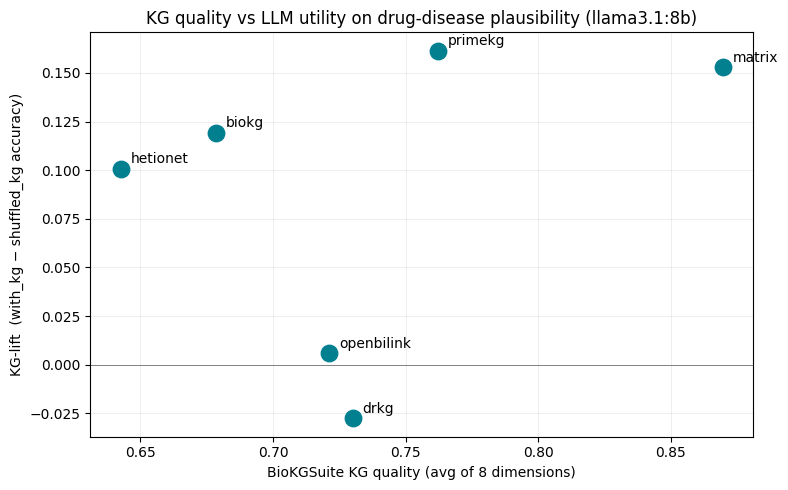

In [ ]:
qdir = BASE / 'results' / 'checkpoints'
per_kg_dim = defaultdict(list)
for f in sorted(qdir.glob('0[1-8]_*.pkl')):
    with open(f, 'rb') as h: payload = pickle.load(h)
    for kg, score in payload.get('summary_scores', {}).items():        # ← changed
        try: per_kg_dim[kg].append(float(score))
        except Exception: pass
quality = {kg: float(np.mean(v)) for kg, v in per_kg_dim.items() if v}
print('Quality scores:', {k: round(v, 3) for k, v in quality.items()})

lift = acc['lift_vs_shuf'].dropna()
xs, ys, labels = [], [], []
for kg in lift.index:
    if kg in quality:
        xs.append(quality[kg]); ys.append(lift[kg]); labels.append(kg)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='gray', linewidth=0.7)
ax.scatter(xs, ys, s=140, color='#028090', zorder=3)
for x, y, lbl in zip(xs, ys, labels):
    ax.annotate(lbl, (x, y), xytext=(7, 4), textcoords='offset points', fontsize=10)
ax.set_xlabel('BioKGSuite KG quality (avg of 7 dimensions)')
ax.set_ylabel('KG-lift  (with_kg − shuffled_kg accuracy)')
ax.set_title(f'KG quality vs LLM utility on drug-disease plausibility ({LLM_TAG})')
ax.grid(alpha=0.3, linewidth=0.5)
fig.tight_layout()
fig.savefig(FIGS / '09_punchline.png', dpi=140)
plt.show()

In [ ]:
quality = {kg.lower(): float(np.mean(v)) for kg, v in per_kg_dim.items() if v}